In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [68]:
from utils.abcd import M_free, M_focal, stability_condition, eigen_q, waist_and_position

# Propagation matrices

We define below the propagation matrices for different cavities configurations:
- linear cavity (concave-concave, planoconcave)
- circular cavity (bow-tie ring)

### Linear cavities

In [69]:
def concave_concave(roc1, roc2, L, l_crystal, index):
    """
    Linear cavity formed by two curved mirrors
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2
    # Geometrical length of propagation in the air
    l_air = L - l_crystal

    # Propagation matrix (starts from mirror 1)
    M = M_focal(f1) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2) @ M_focal(f2) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2)

    return M

In [70]:
def plano_concave(roc, L, l_crystal, index):
    """
    Linear cavity formed by a curved mirror and a flat mirror.
    Same calculation as concave-concave, but with a roc2 = infty
    :param roc: radius of curvature of mirror
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    roc2 = np.inf
    return concave_concave(roc1=roc, roc2=roc2, L=L, l_crystal=l_crystal, index=index)

### Ring cavity

In [71]:
def bow_tie(roc1, roc2, L, d_curved, l_crystal, index):
    """
    Bow tie ring cavity
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param d_curved: distance between the curved mirrors
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2

    # Geometrical length of propagation in the air
    l1 = (L - d_curved) / 2  # L = d_curved + d_flat + 2*d_diag
    l2 = (d_curved - l_crystal) / 2

    # Propagation matrix (starts from middle of flat mirrors)
    M = M_free(l1) @ M_focal(f2) @ M_free(l2) @ M_free(l_crystal/index) @ M_free(l2) @ M_focal(f1) @ M_free(l1)

    return M

# Cavity design

We aim at defining cavity designs based on our experiment constraints (namely finesse and bandwidth).
The idea is to define a "sweep" parameter (cavity length $L$, RoC, etc.) and identify the stability region if it exists. Then based on where the $q_0$ parameter has been chosen, we define a full propagation $q$ parameter over the full cavity to find its waist. For the planoconcave cavity, since the waist is located on the flat mirror, we need to find the position of a target waist instead.

In [72]:
wavelength = 780e-9  # 780 nm

In [73]:
l_crystal = 20e-3  # 20 mm
index = 1.84

In [96]:
roc1 = 100e-3  # 100 mm
roc2 = 100e-3  # 100 mm

f1 = roc1 / 2
f2 = roc2 / 2

## Linear cavities

In [75]:
L_linear = np.linspace(start=0, stop=300, num=600, endpoint=True) * 1e-3  # from 0 to 300 mm

### Concave-concave

In [76]:
waist_values = []
z_waist_values = []
L_stable = []

for L in L_linear:
    # Propagation matrix
    M = concave_concave(roc1=roc1, roc2=roc1, L=L, l_crystal=l_crystal, index=index)

    # Compute q parameter at origin of propagation (M1)
    q0 = eigen_q(M)

    if q0 is None:
        continue

    # Propagation along z axis over cavity length
    z_propagation = np.linspace(start=0, stop=L, num=1000)
    q_propagation = q0 + z_propagation

    # Compute the waist profile along the cavity
    w, z = waist_and_position(q_propagation, wavelength)

    # Find the waist and its position
    i0 = np.argmin(w)
    w0 = w[i0]
    z0 = z[i0]

    waist_values.append(w0)
    z_waist_values.append(z0)
    L_stable.append(L)

#### Plot

### Planoconcave

In [77]:
target_waist = 40e-6 # microns
tol = 5e-6 # 5 microns tolerance

In [78]:
waist_values = []
z_waist_values = []
L_stable = [] # for planoconcave, not only do we need stable cavity, but the length also needs to allow a target waist to exist

for L in L_linear:
    # Propagation matrix
    M = plano_concave(roc=roc1, L=L, l_crystal=l_crystal, index=index)

    # Compute q parameter at origin of propagation (M1)
    q0 = eigen_q(M)

    if q0 is None:
        continue

    # Propagation along z axis over cavity length
    z_propagation = np.linspace(start=0, stop=L, num=1000)
    q_propagation = q0 + z_propagation

    # Compute the waist profile along the cavity
    w, z = waist_and_position(q_propagation, wavelength)

    # Find position where beam radius is closest to target
    i_target = np.argmin(np.abs(w - target_waist))

    if np.abs(w[i_target] - target_waist) < tol:
        w_target_found = w[i_target]
        z_target = z_propagation[i_target]

        waist_values.append(w_target_found)
        z_waist_values.append(z_target)
        L_stable.append(L)
    else:
        continue

In [79]:
waists = np.array(waist_values)
z_waists = np.array(z_waist_values)
L_stable = np.array(L_stable)

print(waists)

[4.00046860e-05 4.07490743e-05]


#### Plot

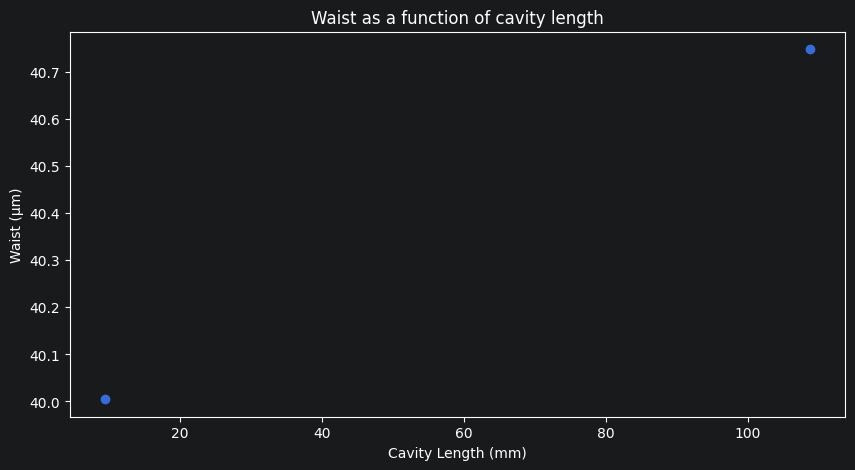

In [80]:
# Plot the waist as a function of the cavity length
plt.figure(figsize=(10, 5))
plt.scatter(L_stable * 1e3, waists * 1e6, label="Waist")
plt.xlabel("Cavity Length (mm)")
plt.ylabel("Waist (µm)")
plt.title("Waist as a function of cavity length")
# plt.legend()
plt.show()

## Bow-tie

The bandwidth of the cavity is determined by its output coupler and length. Based on the colormap of the bandwidth we can set specific range of length to study to match the Rubidium D2 line.
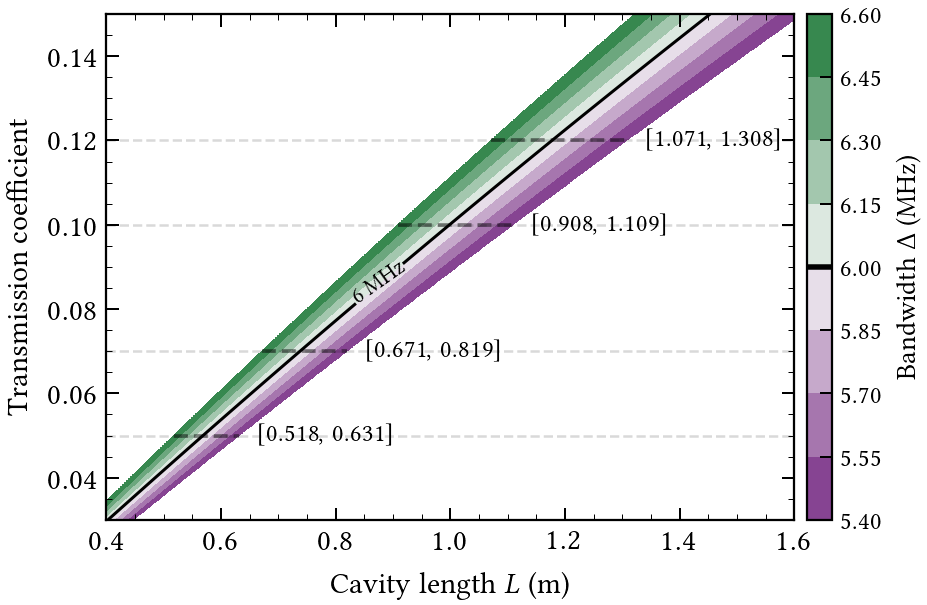

In [113]:
L_ranges = [
    [518, 631],   # T = 5%
    [671, 819],   # T = 7%
    [908, 1109],   # T = 10%
    [1071, 1308],   # T = 12%
]

In [114]:
i = 0 # i between 0 and 3 !
start, stop = L_ranges[i][0], L_ranges[i][1]

L_bowtie = np.linspace(start=start, stop=stop, num=800) * 1e-3 # mm
d_curved_array = np.linspace(start=20, stop=260, num=800) * 1e-3 # distance between curved mirror (mm)

In [116]:
# Curved mirrors waist
waist1_values = []
z1_waist_values = []

# Flat mirrors waist
waist2_values = []
z2_waist_values = []

L_stable = []
# Each entry is an array corresponding to one L
d_curved_stable = []

for L in L_bowtie:
    d_list = []

    w1_list = []
    z1_list = []

    w2_list = []
    z2_list = []
    for d_curved in d_curved_array:
        # Propagation matrix
        # M = bow_tie(roc1=roc1, roc2=roc1, L=L, d_curved=d_curved, l_crystal=l_crystal, index=index)
        # Geometrical length of propagation in the air
        l1 = (L - d_curved) / 2  # L = d_curved + d_flat + 2*d_diag
        l2 = (d_curved - l_crystal) / 2

        # Round trip matrix starting from flat waist
        M2 = (
            M_free(l1)
            @ M_focal(f2)
            @ M_free(l2)
            @ M_free(l_crystal / index)
            @ M_free(l2)
            @ M_focal(f1)
            @ M_free(l1)
        )

        # Round trip matrix starting from curved waist
        M1 = (
            M_free((l_crystal / 2) / index)
            @ M_free(l2)
            @ M_focal(f1)
            @ M_free(2 * l1)
            @ M_focal(f2)
            @ M_free(l2)
            @ M_free((l_crystal / 2) / index)
        )

        q2 = eigen_q(M2)
        q1 = eigen_q(M1)

        if q1 is None or q2 is None:
            continue

        # Waist between curved mirrors
        w1, z1 = waist_and_position(q1, wavelength)

        # Waist between flat mirrors
        w2, z2 = waist_and_position(q2, wavelength)

        d_list.append(d_curved)

        w1_list.append(w1)
        z1_list.append(z1)

        w2_list.append(w2)
        z2_list.append(z2)

    if len(d_list) > 0:

        L_stable.append(L)
        d_curved_stable.append(np.array(d_list))

        waist1_values.append(np.array(w1_list))
        z1_waist_values.append(np.array(z1_list))

        waist2_values.append(np.array(w2_list))
        z2_waist_values.append(np.array(z2_list))

#### Plot

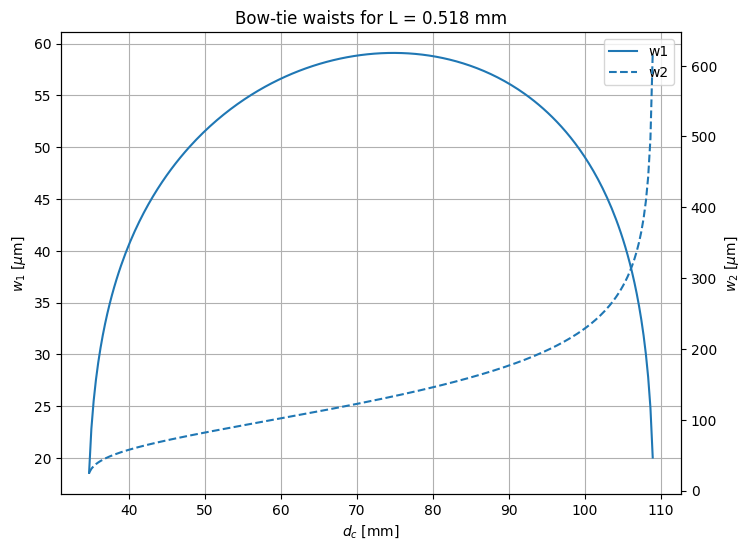

In [112]:
fig, ax1 = plt.subplots(figsize=(8, 6))

i = 0  # fixed L index

# Left axis: w1
ax1.plot(
    d_curved_stable[i] * 1e3,
    waist1_values[i] * 1e6,
    label="w1",
)

ax1.set_xlabel(r"$d_c$ [mm]")
ax1.set_ylabel(r"$w_1$ [$\mu$m]")
ax1.grid()

# Right axis: w2
ax2 = ax1.twinx()

ax2.plot(
    d_curved_stable[i] * 1e3,
    waist2_values[i] * 1e6,
    label="w2",
    linestyle="--",
)

ax2.set_ylabel(r"$w_2$ [$\mu$m]")

# Common title
plt.title(f"Bow-tie waists for L = {L_stable[i]*1e3:.3f} mm")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

In [107]:
target_w1 = 35e-6   # m
tol = 1e-6        # m

L_match = []
d_match = []
w1_match = []

for i, L in enumerate(L_stable):

    w1_arr = waist1_values[i]
    d_arr = d_curved_stable[i]

    # maximum achievable w1 for this L
    w1_max = np.max(w1_arr)

    if w1_max >= target_w1:

        # closest point to target
        i_target = np.argmin(np.abs(w1_arr - target_w1))

        if np.abs(w1_arr[i_target] - target_w1) < tol:
            L_match.append(L)
            d_match.append(d_arr[i_target])
            w1_match.append(w1_arr[i_target])

L_match = np.array(L_match)
d_match = np.array(d_match)
w1_match = np.array(w1_match)

print(f"Found {len(L_match)} geometries close to target.")

Found 298 geometries close to target.


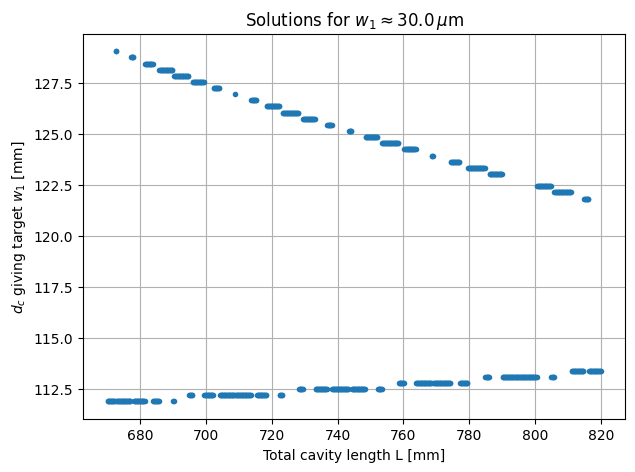

In [106]:
plt.figure(figsize=(7, 5))

plt.plot(L_match * 1e3, d_match * 1e3, ".")

plt.xlabel("Total cavity length L [mm]")
plt.ylabel(r"$d_c$ giving target $w_1$ [mm]")
plt.title(rf"Solutions for $w_1 \approx {target_w1*1e6:.1f}\,\mu$m")
plt.grid()
plt.show()